In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_excel(r"C:\Users\Tpcs.ir\Desktop\project01-ArezuEsmaeili\clean_dataset.xlsx")

In [4]:
df.shape

(60, 17)

In [5]:
df.columns

Index(['customer_id', 'first_name', 'gender', 'age', 'city', 'province',
       'signup_date', 'membership_tier', 'purchase_count', 'avg_order_value',
       'total_spending', 'last_purchase_days', 'payment_method', 'device',
       'discount_used', 'returned_items', 'satisfaction_score'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         60 non-null     int64  
 1   first_name          60 non-null     object 
 2   gender              60 non-null     object 
 3   age                 60 non-null     int64  
 4   city                60 non-null     object 
 5   province            60 non-null     object 
 6   signup_date         60 non-null     object 
 7   membership_tier     60 non-null     object 
 8   purchase_count      60 non-null     int64  
 9   avg_order_value     60 non-null     float64
 10  total_spending      60 non-null     float64
 11  last_purchase_days  60 non-null     int64  
 12  payment_method      60 non-null     object 
 13  device              60 non-null     object 
 14  discount_used       60 non-null     object 
 15  returned_items      60 non-null     int64  
 16  satisfacti

In [7]:
df.describe()

,customer_id,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,1030.500000,43.700000,17.383333,213.156500,3366.428833,198.600000,4.183333,2.983333
std,17.464249,13.946994,10.149880,130.509923,3235.132979,97.843043,2.683861,1.431979
min,1001.000000,19.000000,0.000000,27.630000,0.000000,3.000000,0.000000,1.000000
25%,1015.750000,31.750000,10.750000,108.137500,1167.035000,134.250000,2.000000,2.000000
50%,1030.500000,45.000000,17.000000,165.435000,2128.690000,203.000000,4.000000,3.000000
75%,1045.250000,58.000000,24.500000,324.107500,4213.117500,273.750000,7.000000,4.000000
max,1060.000000,65.000000,35.000000,449.810000,14354.340000,365.000000,8.000000,5.000000


In [8]:
df['gender'].value_counts()

gender
M    35
F    25
Name: count, dtype: int64

In [9]:
# % female customers
round(sum(df['gender']=='F')/df.shape[0]*100,2)

41.67

In [10]:
# number of membership_tier
df['membership_tier'].value_counts()

membership_tier
Gold      19
Bronze    18
VIP       15
Silver     8
Name: count, dtype: int64

In [11]:
# number of discount users is less than people who don't use discount.
df['discount_used'].value_counts()

discount_used
No     34
Yes    26
Name: count, dtype: int64

In [12]:
#no significant difference between mean of purchase_count for categories with and without discount
round(df.groupby('discount_used')['purchase_count'].mean(),2)

discount_used
No     17.29
Yes    17.50
Name: purchase_count, dtype: float64

In [13]:
round(sum(df['discount_used']== 'No')/df.shape[0]*100,2)

56.67

In [14]:
#mean of avg_order_value for category without discount is slightly more than discount users.
df.groupby('discount_used')['avg_order_value'].mean()

discount_used
No     220.700588
Yes    203.291154
Name: avg_order_value, dtype: float64

In [15]:
#satisfaction score of discount users is more than category without discount.
df.groupby('discount_used')['satisfaction_score'].mean()

discount_used
No     2.764706
Yes    3.269231
Name: satisfaction_score, dtype: float64

In [16]:
# mean of returned items for categories with and without discount is almost the same.
df.groupby('discount_used')['returned_items'].mean()

discount_used
No     4.264706
Yes    4.076923
Name: returned_items, dtype: float64

In [17]:
df.groupby('discount_used')['total_spending'].mean()

discount_used
No     3736.741176
Yes    2882.174231
Name: total_spending, dtype: float64

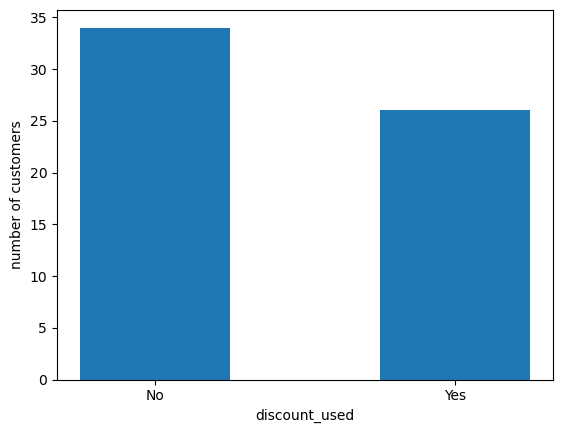

In [18]:
df_grouped=df.groupby('discount_used')['customer_id'].count()
df_grouped
plt.bar(df_grouped.index, df_grouped, width = 0.5)
plt.xlabel('discount_used')
plt.ylabel('number of customers')
plt.xticks(df_grouped.index)
plt.show()

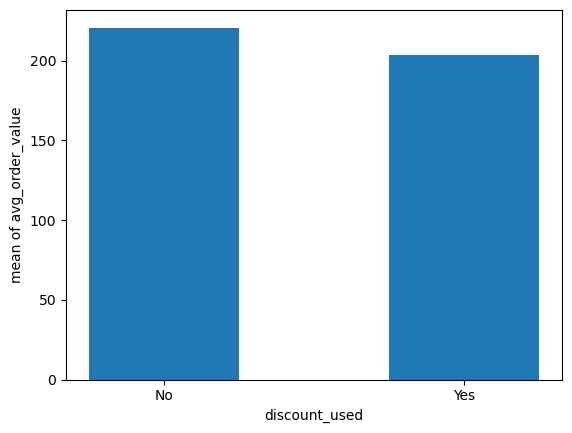

In [19]:
df_grouped=df.groupby('discount_used')['avg_order_value'].mean()
df_grouped
plt.bar(df_grouped.index, df_grouped, width = 0.5)
plt.xlabel('discount_used')
plt.ylabel('mean of avg_order_value')
plt.xticks(df_grouped.index)
plt.show()

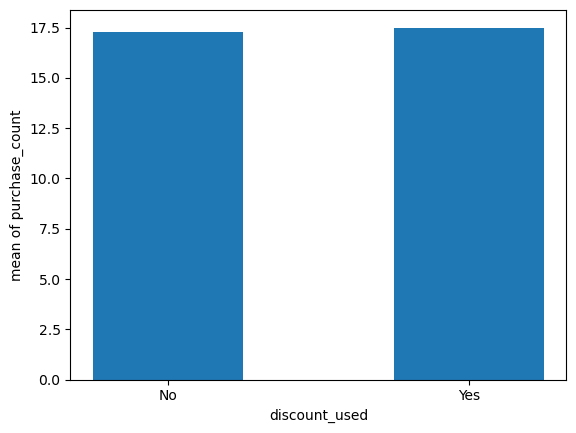

In [20]:
df_grouped=df.groupby('discount_used')['purchase_count'].mean()
df_grouped
plt.bar(df_grouped.index, df_grouped, width = 0.5)
plt.xlabel('discount_used')
plt.ylabel('mean of purchase_count')
plt.xticks(df_grouped.index)
plt.show()

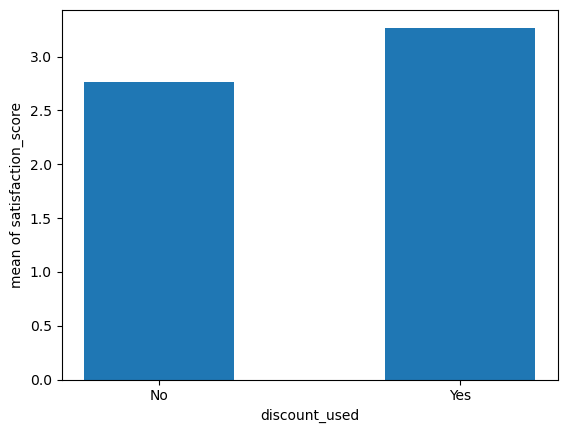

In [21]:
df_grouped=df.groupby('discount_used')['satisfaction_score'].mean()
df_grouped
plt.bar(df_grouped.index, df_grouped, width = 0.5)
plt.xlabel('discount_used')
plt.ylabel('mean of satisfaction_score')
plt.xticks(df_grouped.index)
plt.show()

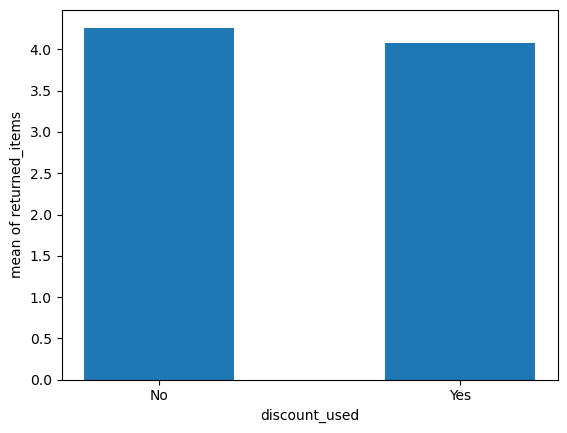

In [22]:
df_grouped=df.groupby('discount_used')['returned_items'].mean()
df_grouped
plt.bar(df_grouped.index, df_grouped, width = 0.5)
plt.xlabel('discount_used')
plt.ylabel('mean of returned_items')
plt.xticks(df_grouped.index)
plt.show()

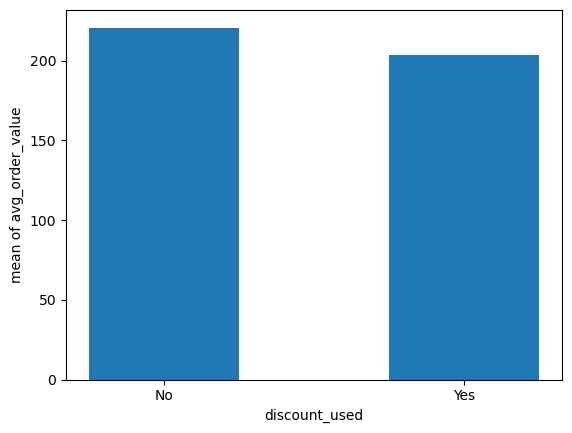

In [23]:
df_grouped=df.groupby('discount_used')['avg_order_value'].mean()
df_grouped
plt.bar(df_grouped.index, df_grouped, width = 0.5)
plt.xlabel('discount_used')
plt.ylabel('mean of avg_order_value')
plt.xticks(df_grouped.index)
plt.show()

<Axes: xlabel='discount_used', ylabel='total_spending'>

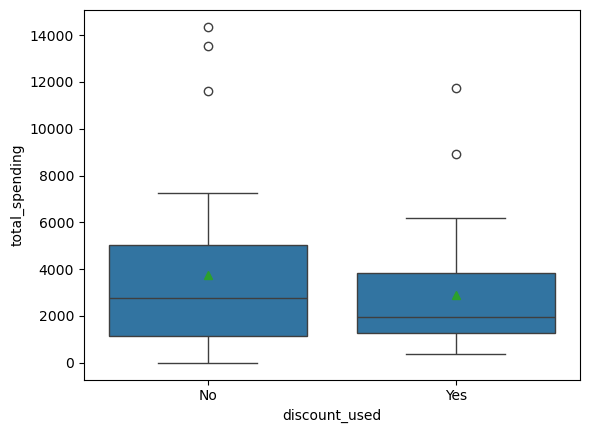

In [24]:
sns.boxplot( x='discount_used', y= 'total_spending', data= df, showmeans= True)

In [25]:
# question 5: effect of discount:
# comparing mean of avg_order_value, mean of returned_items, mean of purchase_count revealed discount doesn't have significant effect on sales.

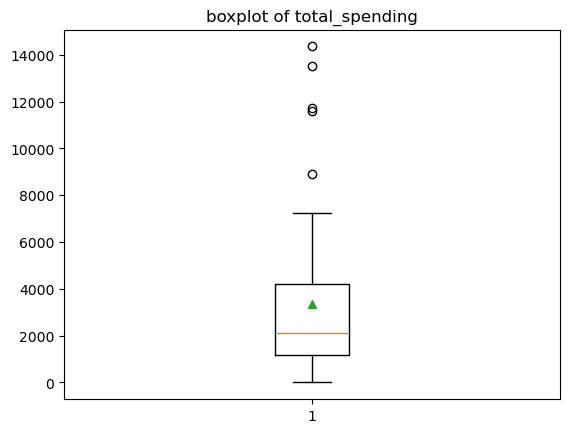

In [26]:
plt.boxplot(df['total_spending'], showmeans = True)
plt.title ( 'boxplot of total_spending')
plt.show()

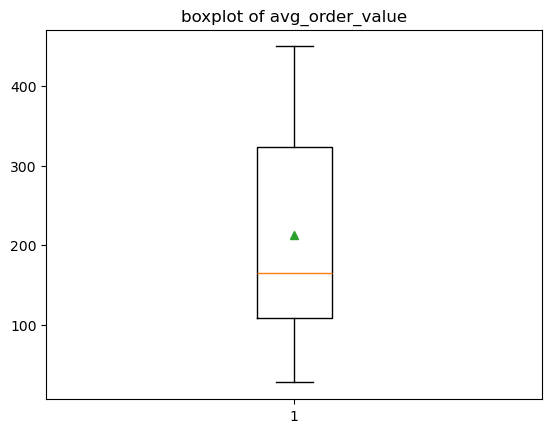

In [27]:
plt.boxplot(df['avg_order_value'], showmeans= True)
plt.title('boxplot of avg_order_value')
plt.show()

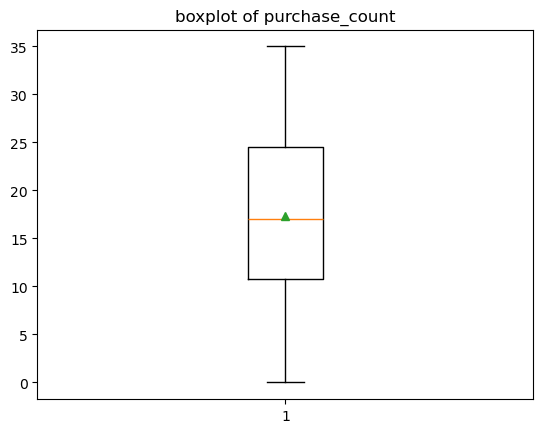

In [28]:
plt.boxplot(df['purchase_count'], showmeans= True)
plt.title('boxplot of purchase_count')
plt.show()

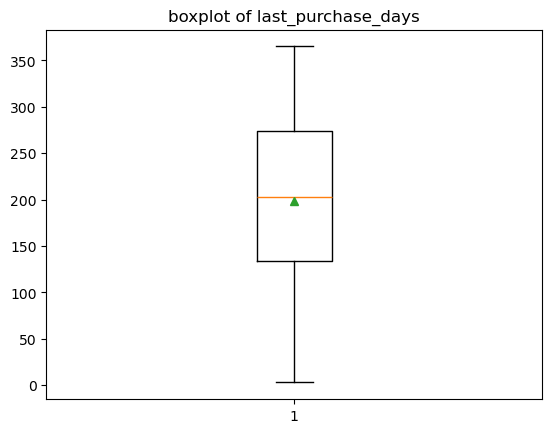

In [29]:
plt.boxplot(df['last_purchase_days'], showmeans= True)
plt.title( 'boxplot of last_purchase_days')
plt.show()

In [30]:
df['city'].value_counts()

city
Tabriz     12
Mashhad    11
Ahvaz       8
Karaj       7
Shiraz      6
Tehran      6
Isfahan     5
Rasht       5
Name: count, dtype: int64

In [31]:
# device is not important.
df['device'].value_counts()

device
Android    22
Web        20
iPhone     18
Name: count, dtype: int64

In [32]:
df['payment_method'].value_counts()

payment_method
Online Wallet    23
Cash             19
Card             18
Name: count, dtype: int64

In [33]:
df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1044,Mina,F,64,Shiraz,Fars,2024-07-27,Gold,33,434.98,14354.34,165,Card,Android,No,7,2
1,1057,Maryam,F,58,Ahvaz,Khuzestan,2024-06-11,Bronze,31,436.54,13532.74,82,Cash,iPhone,No,4,4
2,1012,Arash,M,51,Mashhad,Khorasan,2023-07-22,Gold,27,434.50,11731.50,224,Online Wallet,iPhone,Yes,3,2
3,1009,Kimia,F,61,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,No,8,2
4,1059,Ali,M,57,Isfahan,Isfahan,2023-09-05,Gold,31,287.05,8898.55,224,Online Wallet,iPhone,Yes,0,5


In [34]:
df.tail()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
55,1056,Kimia,F,61,Tabriz,East Azerbaijan,2025-01-25,Silver,1,449.81,449.81,240,Online Wallet,Web,No,4,2
56,1058,Amir,M,47,Tehran,Tehran,2024-09-27,Bronze,5,151.81,759.05,336,Online Wallet,iPhone,No,0,2
57,1042,Sina,M,43,Ahvaz,Khuzestan,2021-12-25,Gold,12,48.06,576.72,350,Online Wallet,Android,Yes,5,5
58,1039,Parsa,M,47,Shiraz,Fars,2022-08-11,Gold,11,36.87,405.57,194,Cash,iPhone,No,1,4
59,1013,Neda,F,39,Karaj,Alborz,2021-02-23,Bronze,1,270.91,270.91,117,Card,Android,No,1,5


In [35]:
df.isna().sum()

customer_id           0
first_name            0
gender                0
age                   0
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        0
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64

total number of customers:


In [36]:
# first question:
# total number of customers: 60
# it seems customer id= 1024 with total_spending = 0 returned all itemes he was ordered.
len(df)

60

In [37]:
# total number of purchases: 1043
df['purchase_count'].sum()

np.int64(1043)

In [38]:
# total revenue : 201985.73
round(df['total_spending'].sum(),2)

np.float64(201985.73)

<Axes: >

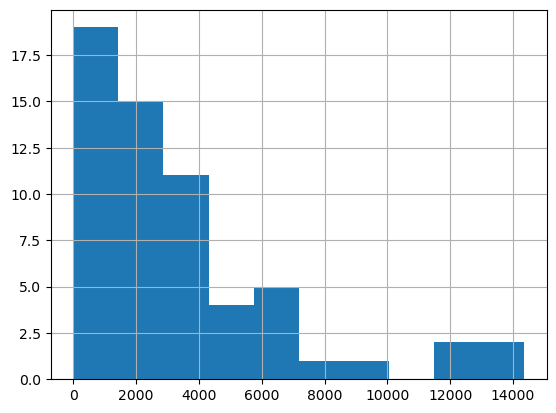

In [39]:
df['total_spending'].hist()

In [40]:
# avg customer satisfaction score is almost 3 .
round(df['satisfaction_score'].mean(),0)

np.float64(3.0)

In [41]:
# second question: which city is the best for advertisement?

In [65]:
city_summary = df.groupby('city')

In [66]:
city_summary['purchase_count'].sum().sort_values(ascending = False)

city
Mashhad    249
Tabriz     189
Karaj      112
Ahvaz      111
Tehran     103
Isfahan     99
Shiraz      98
Rasht       82
Name: purchase_count, dtype: int64

In [67]:
round(city_summary['satisfaction_score'].mean(),2).sort_values(ascending= False)

city
Isfahan    4.40
Ahvaz      3.50
Tabriz     3.00
Mashhad    2.91
Karaj      2.86
Tehran     2.67
Rasht      2.60
Shiraz     2.00
Name: satisfaction_score, dtype: float64

In [68]:
city_summary['customer_id'].count().sort_values(ascending= False)

city
Tabriz     12
Mashhad    11
Ahvaz       8
Karaj       7
Shiraz      6
Tehran      6
Isfahan     5
Rasht       5
Name: customer_id, dtype: int64

In [69]:
city_summary['total_spending'].sum().sort_values(ascending = False)


city
Mashhad    43197.58
Tabriz     36192.49
Karaj      26189.81
Ahvaz      23384.78
Isfahan    21975.32
Shiraz     20715.92
Rasht      15168.54
Tehran     15161.29
Name: total_spending, dtype: float64

In [70]:
round(city_summary['total_spending'].mean(),2).sort_values(ascending = False)


city
Isfahan    4395.06
Mashhad    3927.05
Karaj      3741.40
Shiraz     3452.65
Rasht      3033.71
Tabriz     3016.04
Ahvaz      2923.10
Tehran     2526.88
Name: total_spending, dtype: float64

In [71]:
city_summary['returned_items'].mean().sort_values(ascending = False)

city
Ahvaz      4.875000
Karaj      4.857143
Shiraz     4.833333
Tabriz     4.583333
Isfahan    4.400000
Rasht      4.400000
Tehran     3.500000
Mashhad    2.636364
Name: returned_items, dtype: float64

In [72]:
customers = city_summary['customer_id'].count()
revenue = city_summary['total_spending'].sum()
avg_spending = round(city_summary['total_spending'].mean(),2)
purchases = city_summary['purchase_count'].sum()
satisfaction = round(city_summary['satisfaction_score'].mean(),2)
returned_items = city_summary['returned_items'].sum()
return_share = round(returned_items/returned_items.sum(),2)

In [73]:
city_scores=pd.DataFrame({
    'customers': customers,
    'revenue': revenue,
    'avg_spending': avg_spending,
    'purchases' : purchases,
    'satisfaction': satisfaction,
    'return_share': return_share
})

In [74]:
city_scores

,customers,revenue,avg_spending,purchases,satisfaction,return_share
city,,,,,,
Ahvaz,8,23384.78,2923.10,111,3.50,0.16
Isfahan,5,21975.32,4395.06,99,4.40,0.09
Karaj,7,26189.81,3741.40,112,2.86,0.14
Mashhad,11,43197.58,3927.05,249,2.91,0.12
Rasht,5,15168.54,3033.71,82,2.60,0.09
Shiraz,6,20715.92,3452.65,98,2.00,0.12
Tabriz,12,36192.49,3016.04,189,3.00,0.22
Tehran,6,15161.29,2526.88,103,2.67,0.08


In [75]:
city_scores.columns

Index(['customers', 'revenue', 'avg_spending', 'purchases', 'satisfaction',
       'return_share'],
      dtype='object')

In [76]:

customers_norm =(
    (city_scores['customers']-city_scores['customers'].min())/(city_scores['customers'].max()-city_scores['customers'].min())
)
revenue_norm =(
    (city_scores['revenue']-city_scores['revenue'].min())/(city_scores['revenue'].max()-city_scores['revenue'].min())
)
avg_spending_norm =(
    (city_scores['avg_spending']-city_scores['avg_spending'].min())/(city_scores['avg_spending'].max()-city_scores['avg_spending'].min())
)

purchases_norm =(
    (city_scores['purchases']-city_scores['purchases'].min())/(city_scores['purchases'].max()-city_scores['purchases'].min())
)
satisfaction_norm =(
    (city_scores['satisfaction']-city_scores['satisfaction'].min())/(city_scores['satisfaction'].max()-city_scores['satisfaction'].min())
)
return_share_norm =(
    (city_scores['return_share'].max()-city_scores['return_share'])/(city_scores['return_share'].max()-city_scores['return_share'].min())
)

In [77]:
city_scores_norm = pd.DataFrame({
    'customers_norm' : customers_norm,
    'revenue_norm' : revenue_norm,
    'avg_spending_norm' : avg_spending_norm,
    'purchases_norm' : purchases_norm,
    'satisfaction_norm' : satisfaction_norm,
    'return_share_norm' : return_share_norm
} )
                                

In [78]:
city_scores_norm

,customers_norm,revenue_norm,avg_spending_norm,purchases_norm,satisfaction_norm,return_share_norm
city,,,,,,
Ahvaz,0.428571,0.293316,0.212089,0.173653,0.625000,0.428571
Isfahan,0.000000,0.243043,1.000000,0.101796,1.000000,0.928571
Karaj,0.285714,0.393366,0.650109,0.179641,0.358333,0.571429
Mashhad,0.857143,1.000000,0.749483,1.000000,0.379167,0.714286
Rasht,0.000000,0.000259,0.271296,0.000000,0.250000,0.928571
Shiraz,0.142857,0.198123,0.495546,0.095808,0.000000,0.714286
Tabriz,1.000000,0.750142,0.261838,0.640719,0.416667,0.000000
Tehran,0.142857,0.000000,0.000000,0.125749,0.279167,1.000000


In [79]:
city_final = city_scores_norm.copy()

In [80]:
city_final['final_score'] = (
    city_final ['revenue_norm']*0.25+ city_final['customers_norm']*0.20+ city_final['avg_spending_norm']*0.15+ city_final['purchases_norm']*0.15+
    city_final['satisfaction_norm']*0.15+city_final['return_share_norm']*0.10)

In [81]:
city_final['rank']= city_final['final_score'].rank(
    ascending = False, method= 'min')

In [82]:
city_final = city_final.sort_values('final_score', ascending = False)

In [83]:
city_final[['final_score', 'rank']]

,final_score,rank
city,,
Mashhad,0.812155,1.0
Tabriz,0.585419,2.0
Isfahan,0.468887,3.0
Karaj,0.390840,4.0
Ahvaz,0.353512,5.0
Shiraz,0.238234,6.0
Tehran,0.189309,7.0
Rasht,0.171116,8.0


In [84]:
#Mashhad is the best city for advertisement.

In [85]:
df.groupby('satisfaction_score')['last_purchase_days'].mean().sort_values(ascending = False)

satisfaction_score
1    236.909091
2    226.250000
3    193.375000
5    173.166667
4    158.846154
Name: last_purchase_days, dtype: float64

In [86]:
df.groupby('membership_tier')['last_purchase_days'].mean().sort_values(ascending = False)

membership_tier
Silver    236.000000
Gold      197.421053
Bronze    193.611111
VIP       186.133333
Name: last_purchase_days, dtype: float64

In [87]:
df.groupby('membership_tier')['total_spending'].mean().sort_values(ascending = False)

membership_tier
Silver    4179.926250
Gold      3955.431579
Bronze    3166.656111
VIP       2426.220667
Name: total_spending, dtype: float64

In [88]:
df.groupby('membership_tier')['purchase_count'].mean().sort_values (ascending = False)

membership_tier
VIP       18.866667
Gold      17.052632
Bronze    16.888889
Silver    16.500000
Name: purchase_count, dtype: float64

In [89]:
df['satisfaction_score'].corr(df['last_purchase_days'])

np.float64(-0.29183044062391056)

In [90]:
df['satisfaction_score'].corr(df['total_spending'])

np.float64(-0.047815583107919404)

In [91]:
df['satisfaction_score'].corr(df['purchase_count'])

np.float64(0.0855751687833142)

In [92]:
#customer segmentation based on RFM analysis

In [93]:
customer_score = df.copy()

In [94]:
R_norm = (
(df['last_purchase_days'].max()-df['last_purchase_days'])/(df['last_purchase_days'].max()-df['last_purchase_days'].min()))

In [95]:
f_norm= (
(df['purchase_count']-df['purchase_count'].min())/(df['purchase_count'].max()-df['purchase_count'].min()))

In [96]:
m_norm =(
    (df['total_spending']-df['total_spending'].min())/(df['total_spending'].max()-df['total_spending'].min()))

In [97]:
customer_score = pd.DataFrame({
    'customer_id': df.iloc[:,0],
    'R_norm': R_norm,
    'f_norm': f_norm,
    'm_norm': m_norm})
    

In [98]:
customer_score

,customer_id,R_norm,f_norm,m_norm
0,1044,0.552486,0.942857,1.000000
1,1057,0.781768,0.885714,0.942763
2,1012,0.389503,0.771429,0.817279
3,1009,0.367403,0.971429,0.809192
4,1059,0.389503,0.885714,0.619921
5,1010,0.245856,0.542857,0.504479
6,1050,0.441989,0.857143,0.431786
7,1008,0.469613,0.085714,0.081421
8,1004,0.897790,0.657143,0.426453
9,1055,0.397790,0.542857,0.422745


In [99]:
from sklearn.cluster import KMeans
features = ['R_norm', 'f_norm', 'm_norm']
kmeans = KMeans (n_clusters = 4, random_state =42, n_init=10)
customer_score['cluster']= kmeans.fit_predict(
    customer_score[features]
)

C:\Users\Tpcs.ir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [100]:
cluster_summary = customer_score.groupby ('cluster')[features].mean()

In [101]:
cluster_summary

,R_norm,f_norm,m_norm
cluster,,,
0,0.215470,0.142857,0.073884
1,0.579374,0.840000,0.476134
2,0.245684,0.598214,0.249132
3,0.727819,0.347899,0.120981


In [102]:
segment_map={
    0: 'Needs Attention',
    1: 'Champion',
    2: 'Loyal',
    3: 'At risk'
}
customer_score['segment'] = customer_score['cluster'].map(segment_map)

In [103]:
customer_score[['customer_id', 'cluster', 'segment']]

,customer_id,cluster,segment
0,1044,1,Champion
1,1057,1,Champion
2,1012,1,Champion
3,1009,1,Champion
4,1059,1,Champion
5,1010,2,Loyal
6,1050,1,Champion
7,1008,0,Needs Attention
8,1004,1,Champion
9,1055,2,Loyal


In [104]:
customer_score['segment'].value_counts()

segment
At risk            17
Loyal              16
Champion           15
Needs Attention    12
Name: count, dtype: int64

In [105]:
plot_data = df.merge( customer_score[['customer_id', 'segment']],
on = 'customer_id',
how='inner'
)

KeyError: 'last_purchase days'

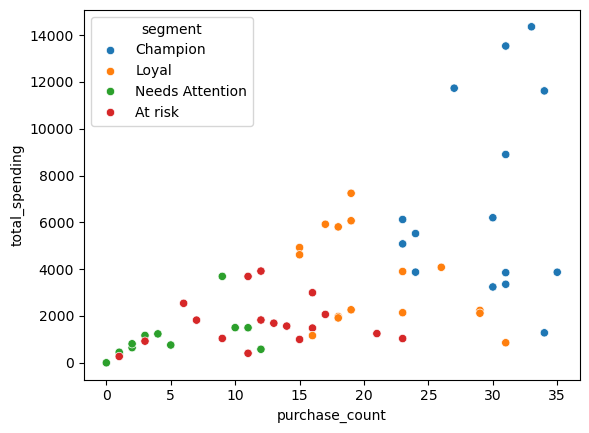

In [106]:
sns.scatterplot(
    data=plot_data,
     x= 'purchase_count',
    y= 'total_spending',
    hue = 'segment'
       
    )
      
for _, row in plot_data.iterrows():
      plt.text(
        str(row['customer_id']),
         row['last_purchase days'],
         row['purchase_count'], fontsize =7)
    
plt.xlabel('purchase_count')
plt.ylabel('total_spending')
plt.title('customer segmentation: Monetary vs Frequency')
plt.legend(title='segment')
plt.show()
    

In [ ]:
# pareto analysis

In [107]:
pareto = df[df['total_spending']>0] [
['customer_id', 'total_spending']].sort_values('total_spending', ascending=False).copy()
pareto['cumulative_spending']= pareto['total_spending'].cumsum()
pareto['cumulative_%'] =(pareto['cumulative_spending']/pareto['total_spending'].sum()*100)
pareto['customer_%'] = (range(1, len(pareto)+1))
pareto['customer_%'] = pareto['customer_%']/len(pareto)*100
pareto

,customer_id,total_spending,cumulative_spending,cumulative_%,customer_%
0,1044,14354.34,14354.34,7.106611,1.694915
1,1057,13532.74,27887.08,13.806460,3.389831
2,1012,11731.50,39618.58,19.614544,5.084746
3,1009,11615.42,51234.00,25.365158,6.779661
4,1059,8898.55,60132.55,29.770692,8.474576
5,1010,7241.47,67374.02,33.355832,10.169492
6,1050,6198.00,73572.02,36.424365,11.864407
8,1004,6121.45,79693.47,39.455000,13.559322
9,1055,6068.22,85761.69,42.459282,15.254237
10,1035,5918.21,91679.90,45.389296,16.949153


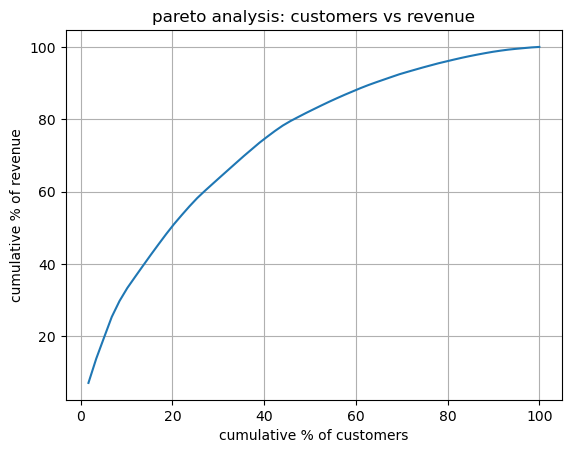

In [108]:
plt.plot(pareto['customer_%'], pareto['cumulative_%'])
plt.xlabel('cumulative % of customers')
plt.ylabel('cumulative % of revenue')
plt.title('pareto analysis: customers vs revenue')
plt.grid()
plt.show()

In [110]:
# result of pareto analysis:
#50% of revenue is generated by 20% of customers.